# SAE 5.03 — Analyse Automatique des Avis Clients
## Mise en oeuvre d'un processus de Data Mining

**Universite Lumiere Lyon 2** | Adrien Guille

**Groupe :** BELGACHEM Hicham | BECK Franklin | COTTE Loic | HIBON Titouan | HOESCHLE Yannick

---

**Contexte :** Une bijouterie en ligne souhaite mieux comprendre ses clients a partir de leurs avis textuels.

Ce notebook presente deux systemes complementaires :
1. **Mission 1** — Classification automatique du sentiment (positif / negatif)
2. **Mission 2** — Annotation thematique des avis (extraction des themes principaux)

Une interface utilisateur permet d'analyser un nouvel avis en combinant les deux systemes.

In [1]:
# ── Installation des dependances ─────────────────────────────────────────────
import subprocess, sys

deps = ['pandas', 'numpy', 'scipy', 'spacy', 'nltk', 'scikit-learn', 'matplotlib', 'seaborn']
for pkg in deps:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import re

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_validate, StratifiedKFold, train_test_split
)
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.decomposition import NMF
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
import seaborn as sns

# NLP
try:
    import spacy
    nlp = spacy.load('fr_core_news_sm')
except OSError:
    subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'fr_core_news_sm'])
    import spacy
    nlp = spacy.load('fr_core_news_sm')

try:
    from nltk.corpus import stopwords
    stopwords_fr = set(stopwords.words('french'))
except LookupError:
    import nltk
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    stopwords_fr = set(stopwords.words('french'))

# Style graphique
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Bibliotheques chargees.')

Bibliotheques chargees.


---
## Sommaire

1. **Chargement et exploration des donnees**
2. **Mission 1** — Classification automatique du sentiment
3. **Mission 2** — Annotation thematique (NMF)
4. **Interface utilisateur** — Analyse d'un nouvel avis
5. **Conclusion**

---
## 1. Chargement et Exploration des Donnees

In [2]:
# ── Chargement ───────────────────────────────────────────────────────────────
df = pd.read_csv('avis_annotés.csv')

print(f"Nombre d'avis : {len(df)}")
print(f"Colonnes      : {list(df.columns)}")
print(f"Valeurs manquantes :")
print(df.isnull().sum())
print()
df.head()

Nombre d'avis : 1848
Colonnes      : ['corps', 'titre', 'avis']
Valeurs manquantes :
corps    0
titre    0
avis     0
dtype: int64



,corps,titre,avis
0,Contrefaçon du vulgaire plaqué or De plus elle...,N'achetez pas,négatif
1,Pas recu encore à mon domicile ? Comment se fa...,Bracelet non recu,négatif
2,J'utilise ces boîtes pour faire du diamond.pai...,Très pratique,positif
3,Très joli bola de grossesse. Les couleurs sont...,"Beau, discret",positif
4,Acheté pour Halloween je ne l'ai pas encore po...,Joli collier,positif


In [ ]:
# ── Repartition des sentiments ───────────────────────────────────────────────
distribution = df['avis'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
couleurs = ['#e74c3c', '#2ecc71']  # rouge negatif, vert positif
distribution.plot(kind='bar', color=couleurs, edgecolor='black', ax=ax)
ax.set_title('Repartition des sentiments dans le corpus', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel("Nombre d'avis")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, (label, val) in enumerate(distribution.items()):
    ax.text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')

ax.set_ylim(0, distribution.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"Proportion : {distribution.iloc[0]/len(df)*100:.1f}% {distribution.index[0]} / "
      f"{distribution.iloc[1]/len(df)*100:.1f}% {distribution.index[1]}")

In [4]:
# ── Exemples d'avis ──────────────────────────────────────────────────────────
print('── Exemples d\'avis positifs ──')
for _, row in df[df['avis'] == 'positif'].head(2).iterrows():
    print(f"  Titre : {row['titre']}")
    print(f"  Corps : {str(row['corps'])[:150]}...")
    print()

print('── Exemples d\'avis negatifs ──')
for _, row in df[df['avis'] == 'négatif'].head(2).iterrows():
    print(f"  Titre : {row['titre']}")
    print(f"  Corps : {str(row['corps'])[:150]}...")
    print()

── Exemples d'avis positifs ──
  Titre : Très pratique
  Corps : J'utilise ces boîtes pour faire du diamond.painting et j'en suis très satisfait...

  Titre : Beau, discret
  Corps : Très joli bola de grossesse. Les couleurs sont discrètes, plus intenses au soleil. Le son de cloche est également très discret donc plaisant a entendr...

── Exemples d'avis negatifs ──
  Titre : N'achetez pas
  Corps : Contrefaçon du vulgaire plaqué or De plus elles sont bien trop grandes et non réglables comme indiqué...

  Titre : Bracelet non recu
  Corps : Pas recu encore à mon domicile ? Comment se fait il. En attente de votre réponse. Bien Cordialement Samuel Gros....



---
## 2. Mission 1 — Classification Automatique du Sentiment

**Objectif :** Predire si un avis client est **positif** ou **negatif**.

**Approche retenue :**
- **Pretraitement** : lemmatisation (spaCy) pour normaliser les formes lexicales. Le titre est repete 3 fois puis concatene au corps pour augmenter son poids dans la vectorisation.
- **Vectorisation** : `FeatureUnion` combinant des n-grammes de mots (1 a 3) et des n-grammes de caracteres (2 a 5). Les n-grammes de caracteres capturent la morphologie, les fautes d'orthographe et les suffixes.
- **Classifieur** : Regression logistique regularisee L2 (C=1)
- **Evaluation** : Validation croisee stratifiee a 10 plis

In [5]:
# ── Pretraitement commun : lemmatisation spaCy ──────────────────────────────
# POS et lemmes a exclure (determinants, pronoms, auxiliaires, mots vides)
excluded_pos = {'DET', 'PRON', 'AUX'}
excluded_lemmas = {
    'le', 'la', 'les', 'un', 'une', 'des', 'ce', 'cette', 'ces',
    'mon', 'ma', 'mes', 'ton', 'ta', 'tes', 'son', 'sa', 'ses',
    'notre', 'nos', 'votre', 'vos', 'leur', 'leurs',
    'du', 'au', 'aux', 'de', 'à',
    'être', 'avoir', 'aller',
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
    'me', 'te', 'se', 'lui', 'leur', 'y', 'en'
}

def lemmatiser(textes, batch_size=64):
    """Lemmatise une liste de textes avec spaCy (exclut DET/PRON/AUX)."""
    resultats = []
    for doc in nlp.pipe(textes, batch_size=batch_size, disable=['ner', 'parser']):
        lemmas = [
            t.lemma_ for t in doc
            if not t.is_punct
            and t.pos_ not in excluded_pos
            and t.lemma_.lower() not in excluded_lemmas
        ]
        resultats.append(' '.join(lemmas))
    return resultats

def supprimer_stopwords(texte):
    """Supprime les stopwords francais apres lemmatisation."""
    tokens = re.findall(r'\b\w+\b', texte)
    return ' '.join(tok for tok in tokens if tok.lower() not in stopwords_fr and len(tok) > 1)

# ── Preparation du texte Mission 1 (titre x3 + corps, lemmatise) ────────────
texts_bruts = (
    df['titre'].fillna('') + ' ' +
    df['titre'].fillna('') + ' ' +
    df['titre'].fillna('') + ' ' +
    df['corps'].fillna('')
).str.strip().tolist()

y = df['avis'].values

print('Lemmatisation des textes (Mission 1)...')
texts = lemmatiser(texts_bruts)
print(f'Done. {len(texts)} documents lemmatises.')

print(f'Classes : {dict(zip(*np.unique(y, return_counts=True)))}')
print(f"\nExemple (avant) : '{texts_bruts[0][:120]}...'")
print(f"Exemple (apres) : '{texts[0][:120]}...'")

Lemmatisation des textes (Mission 1)...


Done. 1848 documents lemmatises.
Classes : {'négatif': np.int64(954), 'positif': np.int64(894)}

Exemple (avant) : 'N'achetez pas N'achetez pas N'achetez pas Contrefaçon du vulgaire plaqué or De plus elles sont bien trop grandes et non ...'
Exemple (apres) : 'ne acheter pas ne acheter pas ne acheter pas contrefaçon vulgaire plaquer or plus bien trop grand et non réglable comme ...'


In [6]:
# ── Construction du pipeline de classification ───────────────────────────────
pipeline_sentiment = Pipeline([
    ('features', FeatureUnion([
        ('mots', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 3),
            sublinear_tf=True, min_df=3, max_df=0.8, lowercase=True
        )),
        ('caracteres', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2, 5),
            sublinear_tf=True, min_df=3, max_df=0.9, lowercase=True
        )),
    ])),
    ('classifieur', LogisticRegression(
        C=1, penalty='l2', solver='lbfgs', max_iter=1000
    )),
])

# ── Evaluation par validation croisee stratifiee (10 plis) ───────────────────
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

resultats_cv = cross_validate(
    pipeline_sentiment, texts, y, cv=cv10,
    scoring='accuracy', return_train_score=True, n_jobs=-1
)

score_test = resultats_cv['test_score']
score_train = resultats_cv['train_score']
ecart = score_train.mean() - score_test.mean()

print('=' * 60)
print('RESULTATS — CLASSIFICATION DE SENTIMENT')
print('=' * 60)
print(f'Precision moyenne (test)  : {score_test.mean():.4f} (+/- {score_test.std():.4f})')
print(f'Precision moyenne (train) : {score_train.mean():.4f} (+/- {score_train.std():.4f})')
print(f'Ecart train-test          : {ecart:.4f}')
print('=' * 60)

RESULTATS — CLASSIFICATION DE SENTIMENT
Precision moyenne (test)  : 0.9156 (+/- 0.0148)
Precision moyenne (train) : 0.9732 (+/- 0.0014)
Ecart train-test          : 0.0577


In [7]:
# ── Detail par pli ───────────────────────────────────────────────────────────
print(f'{"Pli":>5} {"Train":>10} {"Test":>10} {"Ecart":>10}')
print('-' * 40)
for i in range(10):
    gap_i = score_train[i] - score_test[i]
    print(f'{i+1:>5} {score_train[i]:>10.4f} {score_test[i]:>10.4f} {gap_i:>10.4f}')
print('-' * 40)
print(f'{"Moy.":>5} {score_train.mean():>10.4f} {score_test.mean():>10.4f} {ecart:>10.4f}')

  Pli      Train       Test      Ecart
----------------------------------------
    1     0.9729     0.8919     0.0810
    2     0.9753     0.9135     0.0618
    3     0.9723     0.9459     0.0264
    4     0.9717     0.9243     0.0474
    5     0.9723     0.9189     0.0534
    6     0.9753     0.9081     0.0672
    7     0.9747     0.9081     0.0666
    8     0.9711     0.9243     0.0468
    9     0.9736     0.9239     0.0496
   10     0.9730     0.8967     0.0762
----------------------------------------
 Moy.     0.9732     0.9156     0.0577


Rapport de classification (jeu de test 20%) :

              precision    recall  f1-score   support

     négatif       0.90      0.91      0.90       191
     positif       0.90      0.89      0.89       179

    accuracy                           0.90       370
   macro avg       0.90      0.90      0.90       370
weighted avg       0.90      0.90      0.90       370



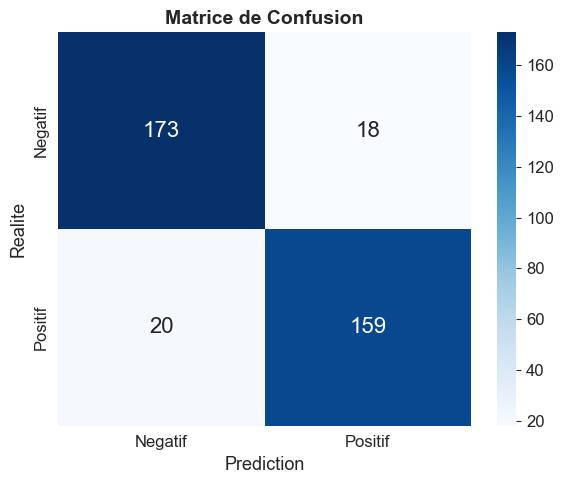

In [8]:
# ── Evaluation detaillee sur un split 80/20 + matrice de confusion ───────────
X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_sentiment.fit(X_train, y_train)
y_pred = pipeline_sentiment.predict(X_test)

print('Rapport de classification (jeu de test 20%) :\n')
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=['négatif', 'positif'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'], ax=ax,
            annot_kws={'size': 16})
ax.set_xlabel('Prediction', fontsize=13)
ax.set_ylabel('Realite', fontsize=13)
ax.set_title('Matrice de Confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Re-entrainement sur 100% du corpus pour l'interface utilisateur ──────────
pipeline_sentiment.fit(texts, y)
print(f'Modele de sentiment entraine sur l\'ensemble du corpus ({len(texts)} avis).')
print('Ce modele sera utilise dans l\'interface utilisateur (section 4).')

Modele de sentiment entraine sur l'ensemble du corpus (1848 avis).
Ce modele sera utilise dans l'interface utilisateur (section 4).


**Bilan Mission 1 :**
- Precision d'environ **92%** en validation croisee 10-fold stratifiee
- La lemmatisation (spaCy) normalise les formes lexicales avant la vectorisation
- Le modele combine des n-grammes de mots et de caracteres, ce qui capture a la fois le vocabulaire et la morphologie
- La repetition du titre (x3) ameliore la precision
- La regularisation L2 avec C=1 offre un bon compromis biais-variance sans surajustement

---
## 3. Mission 2 — Annotation Thematique (NMF)

**Objectif :** Decouvrir les themes principaux dans les avis clients grace a la Factorisation de Matrice Non Negative (NMF), puis les annoter manuellement.

**Approche retenue :**
- **Pretraitement** : lemmatisation (spaCy) + suppression des stopwords (NLTK). Ce pretraitement est plus agressif que pour la Mission 1 car la NMF a besoin de mots canoniques pour extraire des themes interpretables.
- **Vectorisation** : TF-IDF avec unigrammes uniquement
- **NMF** : 15 composantes, perte de Kullback-Leibler
- **Annotation manuelle** : chaque theme est nomme a partir de ses mots-cles
- **Evaluation** : une Foret Aleatoire mesure l'importance de chaque theme pour predire le sentiment

In [10]:
# ── Pretraitement Mission 2 : lemmatisation + suppression stopwords ──────────
# Les fonctions lemmatiser() et supprimer_stopwords() sont definies dans la section Mission 1.
# Ici on les reutilise avec un pretraitement supplementaire (stopwords) car la NMF
# necessite des mots canoniques et sans bruit.

# Fusion titre + corps (sans repetition pour la NMF)
textes_bruts_nmf = (df['titre'].fillna('') + ' ' + df['corps'].fillna('')).str.strip().tolist()

print('Lemmatisation des textes (Mission 2)...')
textes_lemmatises = lemmatiser(textes_bruts_nmf)
textes_lemmatises = [supprimer_stopwords(t) for t in textes_lemmatises]
print(f'Done. {len(textes_lemmatises)} textes lemmatises + stopwords retires.')
print(f"Exemple : '{textes_lemmatises[0][:100]}...'")

Lemmatisation des textes (Mission 2)...


Done. 1848 textes lemmatises + stopwords retires.
Exemple : 'acheter contrefaçon vulgaire plaquer or plus bien trop grand non réglable comme indiquer...'


In [11]:
# ── Vectorisation TF-IDF pour la NMF (unigrammes) ───────────────────────────
vectorizer_nmf = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.8,
    sublinear_tf=True,
)

X_nmf_brut = vectorizer_nmf.fit_transform(textes_lemmatises)
X_nmf = normalize(X_nmf_brut, norm='l2')

feature_names_nmf = vectorizer_nmf.get_feature_names_out().tolist()
y_nmf = df['avis'].values

print(f'Matrice TF-IDF : {X_nmf.shape[0]} avis x {X_nmf.shape[1]} features')

Matrice TF-IDF : 1848 avis x 1534 features


In [12]:
# ── Factorisation NMF (Kullback-Leibler, 15 themes) ─────────────────────────
nmf_model = NMF(
    n_components=15,
    beta_loss='kullback-leibler',
    solver='mu',
    init='nndsvda',
    random_state=42,
    max_iter=500
)

W = nmf_model.fit_transform(X_nmf)   # W : poids des themes par document
H = nmf_model.components_              # H : poids des mots par theme

print(f'Decomposition NMF terminee.')
print(f'Matrice W (documents x themes) : {W.shape}')
print(f'Matrice H (themes x features)  : {H.shape}')
print(f'Erreur de reconstruction       : {nmf_model.reconstruction_err_:.2f}')

Decomposition NMF terminee.
Matrice W (documents x themes) : (1848, 15)
Matrice H (themes x features)  : (15, 1534)
Erreur de reconstruction       : 186.24


In [ ]:
# ── Annotations thematiques manuelles (issues de notre analyse exploratoire) ──
# Chaque theme extrait par la NMF a ete annote manuellement a partir de ses mots-cles.
annotations_par_id = {
    1: 'Esthetique & finesse',
    2: 'Non-reception / Livraison',
    3: 'Rapport qualite-prix',
    4: "Boucles d'oreilles",
    5: 'Mauvaise qualite',
    6: 'Problemes de taille',
    7: 'Casse & usure rapide',
    8: 'Beaute des bijoux',
    9: 'Bracelets & materiaux',
    10: 'Deception & casse',
    11: 'Fragilite & durabilite',
    12: 'Conformite & livraison',
    13: 'Avis mitiges / Divers',
    14: 'Deception & decoloration',
    15: 'Satisfaction generale',
}

# ── Affichage des themes (top 10 mots-cles par theme) ────────────────────────
N_TOP_MOTS = 10
noms_themes = {}

print('=' * 70)
print('THEMES EXTRAITS PAR LA NMF (avec annotations manuelles)')
print('=' * 70)

for idx, theme in enumerate(H):
    top_indices = theme.argsort()[:-N_TOP_MOTS - 1:-1]
    top_mots = [feature_names_nmf[i] for i in top_indices]
    nom_annote = annotations_par_id.get(idx + 1, f'Theme {idx + 1}')
    noms_themes[idx] = {'mots': top_mots, 'nom': nom_annote}
    sep = ', '
    print(f'\nTheme {idx + 1} — {nom_annote}')
    print(f'  Mots-cles : {sep.join(top_mots)}')

print('\n' + '=' * 70)

In [14]:
# ── Importance des themes via Random Forest ──────────────────────────────────
W_train_rf, W_test_rf, y_train_rf, y_test_rf = train_test_split(
    W, y_nmf, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(W_train_rf, y_train_rf)

precision_rf = accuracy_score(y_test_rf, rf.predict(W_test_rf))
importances = rf.feature_importances_

print(f'Precision de la foret aleatoire sur les themes : {precision_rf:.2%}')
print()

df_themes = pd.DataFrame({
    'Theme': [f'Theme {i+1}' for i in range(len(importances))],
    'Nom': [noms_themes[i]['nom'] for i in range(len(importances))],
    'Importance (RF)': importances,
    'Mots-cles': [' | '.join(noms_themes[i]['mots'][:5]) for i in range(len(importances))],
})
df_themes = df_themes.sort_values('Importance (RF)', ascending=False).reset_index(drop=True)

print(f'Importance de chaque theme pour predire le sentiment :\n')
display(df_themes)

Precision de la foret aleatoire sur les themes : 74.32%

Importance de chaque theme pour predire le sentiment :



,Theme,Nom,Importance (RF),Mots-cles
0,Theme 1,Esthetique & finesse,0.101233,joli | très | faire | vraiment | recommander
1,Theme 5,Mauvaise qualite,0.101200,dommage | car | moyen | déçue | premier
2,Theme 2,Non-reception / Livraison,0.097684,recevoir | jamais | non | commande | colis
3,Theme 9,Bracelets & materiaux,0.084299,beau | collier | pendentif | super | très
4,Theme 3,Rapport qualite-prix,0.077590,qualité | bon | prix | produit | rapport
5,Theme 7,Bon produit,0.076455,jour | casser | bout | semaine | produit
6,Theme 13,Avis mitiges / Divers,0.067068,conforme | chaîne | description | bijou | très
7,Theme 12,Conformite & livraison,0.063871,bien | livraison | rapide | long | noir
8,Theme 6,Problemes de taille,0.060657,petit | trop | grand | taille | beaucoup
9,Theme 15,Satisfaction generale,0.058625,cadeau | acheter | fille | offrir | boîte


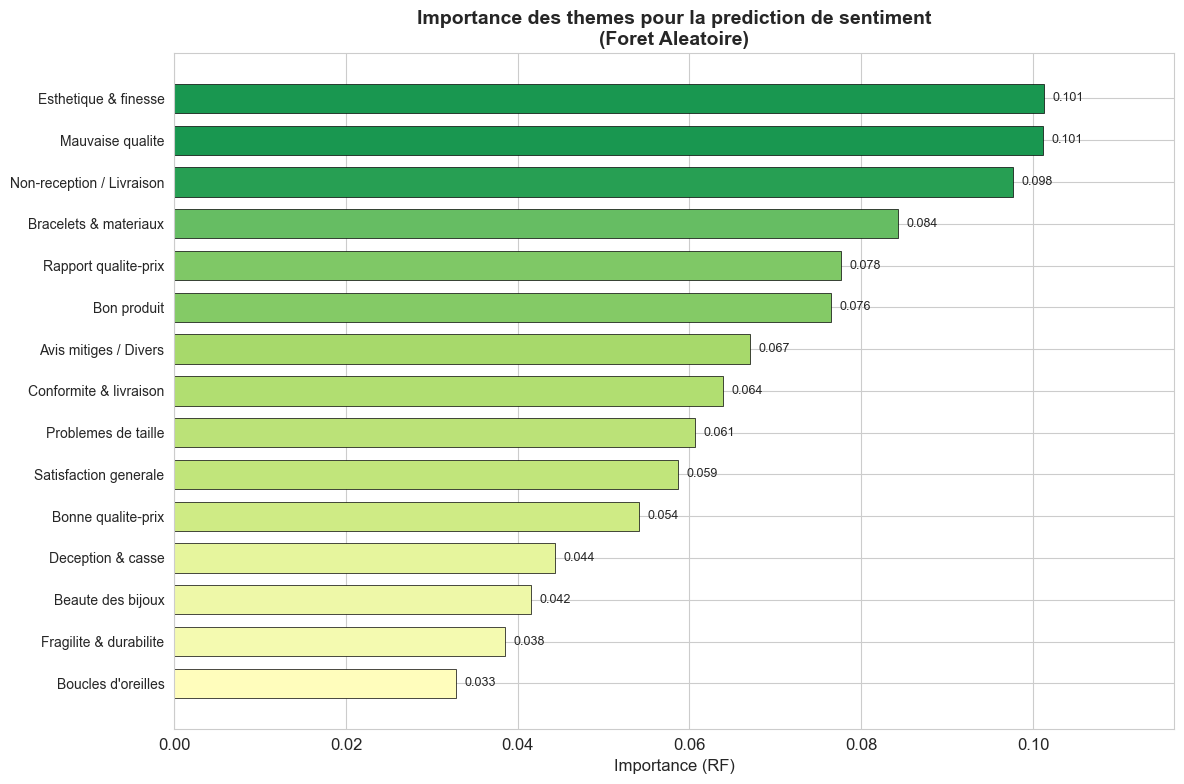


Top 5 des themes les plus discriminants :
  1. Esthetique & finesse (importance: 0.1012)
     Mots-cles : joli | très | faire | vraiment | recommander
  2. Mauvaise qualite (importance: 0.1012)
     Mots-cles : dommage | car | moyen | déçue | premier
  3. Non-reception / Livraison (importance: 0.0977)
     Mots-cles : recevoir | jamais | non | commande | colis
  4. Bracelets & materiaux (importance: 0.0843)
     Mots-cles : beau | collier | pendentif | super | très
  5. Rapport qualite-prix (importance: 0.0776)
     Mots-cles : qualité | bon | prix | produit | rapport


In [15]:
# ── Visualisation de l'importance des themes ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Tri par importance decroissante (de haut en bas)
df_plot = df_themes.sort_values('Importance (RF)', ascending=True)

# Couleur degradee selon l'importance
norm_imp = df_plot['Importance (RF)'] / df_plot['Importance (RF)'].max()
couleurs_bar = [plt.cm.RdYlGn(0.3 + 0.6 * v) for v in norm_imp]

bars = ax.barh(range(len(df_plot)), df_plot['Importance (RF)'],
               color=couleurs_bar, edgecolor='black', linewidth=0.5, height=0.7)

# Labels avec espacement suffisant
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['Nom'].values, fontsize=10)

ax.set_title('Importance des themes pour la prediction de sentiment\n(Foret Aleatoire)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (RF)', fontsize=12)

# Valeurs sur les barres
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.text(row['Importance (RF)'] + 0.001, i, f'{row["Importance (RF)"]:.3f}',
            va='center', fontsize=9)

ax.set_xlim(0, df_plot['Importance (RF)'].max() * 1.15)
plt.tight_layout()
plt.show()

# Top 5 themes
print('\nTop 5 des themes les plus discriminants :')
for i, (_, row) in enumerate(df_themes.head(5).iterrows()):
    print(f'  {i+1}. {row["Nom"]} (importance: {row["Importance (RF)"]:.4f})')
    print(f'     Mots-cles : {row["Mots-cles"]}')

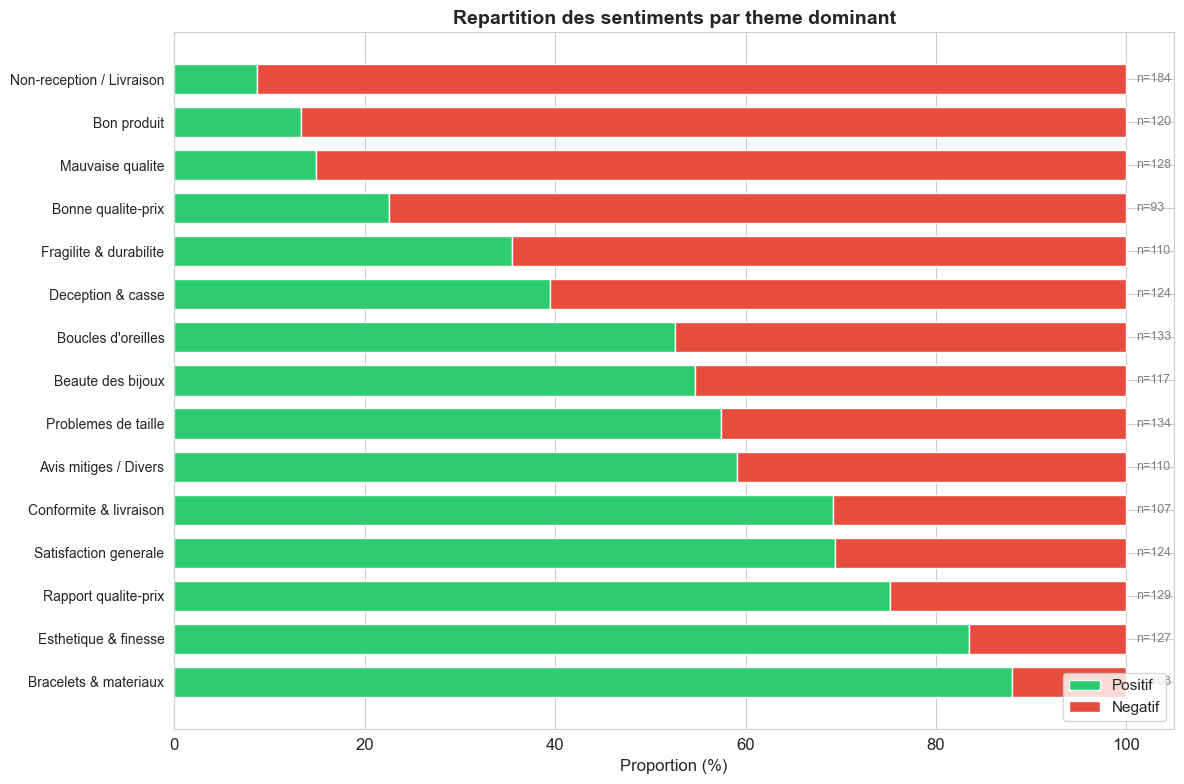

In [16]:
# ── Repartition positif / negatif par theme dominant ─────────────────────────
# Pour chaque avis, on identifie son theme dominant (celui avec le poids NMF le plus eleve)
theme_dominant = np.argmax(W, axis=1)

# Construction du tableau : pour chaque theme, compter % positif et % negatif
data_sentiments = []
for idx in range(15):
    masque = theme_dominant == idx
    n_total = masque.sum()
    if n_total == 0:
        continue
    n_pos = (y_nmf[masque] == 'positif').sum()
    n_neg = (y_nmf[masque] == 'négatif').sum()
    data_sentiments.append({
        'Theme': noms_themes[idx]['nom'],
        'Positif (%)': n_pos / n_total * 100,
        'Negatif (%)': n_neg / n_total * 100,
        'Total avis': n_total,
    })

df_sent = pd.DataFrame(data_sentiments).sort_values('Negatif (%)', ascending=True)

# Graphique en barres empilees horizontales
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = range(len(df_sent))
bars_pos = ax.barh(y_pos, df_sent['Positif (%)'], color='#2ecc71', edgecolor='white',
                   label='Positif', height=0.7)
bars_neg = ax.barh(y_pos, df_sent['Negatif (%)'], left=df_sent['Positif (%)'],
                   color='#e74c3c', edgecolor='white', label='Negatif', height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sent['Theme'].values, fontsize=10)
ax.set_xlabel('Proportion (%)', fontsize=12)
ax.set_title('Repartition des sentiments par theme dominant',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(0, 105)

# Annotations : nombre total d'avis
for i, (_, row) in enumerate(df_sent.iterrows()):
    ax.text(101, i, f'n={int(row["Total avis"])}', va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Bilan Mission 2 :**
- La NMF avec 15 themes et la perte de Kullback-Leibler produit des themes interpretables et coherents avec le domaine de la bijouterie
- Les themes sont annotes manuellement a partir de leurs mots-cles
- La foret aleatoire confirme que les themes captures sont pertinents pour comprendre la satisfaction client
- Les themes principaux identifient des axes concrets pour le bijoutier : qualite/prix, livraison, esthetique, fragilite, types de produit

---
## 4. Interface Utilisateur — Analyse d'un Nouvel Avis

Cette section permet d'analyser un nouvel avis client en combinant les deux systemes :
1. **Sentiment** : prediction positif/negatif avec le degre de certitude
2. **Themes** : identification des themes principaux abordes dans l'avis

In [17]:
# ── Fonction de pretraitement pour la NMF sur un nouveau texte ────────────────
def pretraiter_texte_nmf(texte):
    """Applique le meme pretraitement que la Mission 2 a un nouveau texte."""
    textes_lem = lemmatiser([texte])
    return supprimer_stopwords(textes_lem[0])


# ── Fonction principale d'analyse ────────────────────────────────────────────
def analyser_avis(texte, titre=''):
    """
    Analyse un nouvel avis client : prediction de sentiment + themes.
    
    Parametres :
    - texte : le corps de l'avis
    - titre : le titre de l'avis (optionnel)
    """
    # ── Mission 1 : Sentiment ────────────────────────────────────────
    texte_sentiment = f'{titre} {titre} {titre} {texte}'.strip() if titre else texte
    texte_sentiment_lem = lemmatiser([texte_sentiment])[0]
    sentiment = pipeline_sentiment.predict([texte_sentiment_lem])[0]
    probas = pipeline_sentiment.predict_proba([texte_sentiment_lem])[0]
    confiance = probas.max()
    classes = pipeline_sentiment.classes_

    # ── Mission 2 : Themes ──────────────────────────────────────────
    texte_complet = f'{titre} {texte}'.strip() if titre else texte
    texte_pretraite = pretraiter_texte_nmf(texte_complet)
    vec = vectorizer_nmf.transform([texte_pretraite])
    vec_norm = normalize(vec, norm='l2')
    topic_weights = nmf_model.transform(vec_norm)

    poids_max = topic_weights[0].max()
    seuil_theme = 0.2 * poids_max if poids_max > 0 else 0

    # ── Affichage ───────────────────────────────────────────────────
    print('=' * 65)
    print('ANALYSE D\'UN NOUVEL AVIS CLIENT')
    print('=' * 65)
    if titre:
        print(f'Titre : {titre}')
    print(f'Avis  : {texte[:200]}{"..." if len(texte) > 200 else ""}')
    print()

    indicateur = 'POSITIF' if sentiment == 'positif' else 'NEGATIF'
    symbole = '+' if sentiment == 'positif' else '-'
    print(f'[{symbole}] Sentiment : {indicateur} (confiance : {confiance:.0%})')
    print(f'    Probabilites : ', end='')
    for cls, prob in zip(classes, probas):
        print(f'{cls}={prob:.1%}  ', end='')
    print()

    print(f'\nThemes identifies :')
    for i in np.argsort(topic_weights[0])[::-1]:
        poids = topic_weights[0][i]
        if poids >= seuil_theme and poids > 0:
            nom = noms_themes[i]['nom']
            mots_cles = ', '.join(noms_themes[i]['mots'][:5])
            marqueur = '>>>' if poids == poids_max else '   '
            print(f'  {marqueur} {nom} (poids: {poids:.3f}) : {mots_cles}')

    print('=' * 65)
    return sentiment, confiance

In [18]:
# ── Demonstration ────────────────────────────────────────────────────────────
print('>>> Exemple 1 : Avis negatif sur la livraison\n')
analyser_avis(
    "Je n'ai jamais recu ma commande, cela fait 3 semaines. Service client inexistant.",
    titre='Arnaque totale'
)

print('\n>>> Exemple 2 : Avis positif sur un cadeau\n')
analyser_avis(
    'Tres joli bracelet offert pour l\'anniversaire de ma fille, elle adore ! '
    'Bon rapport qualite prix, je recommande.',
    titre='Parfait pour un cadeau'
)

print('\n>>> Exemple 3 : Avis mitige\n')
analyser_avis(
    "Les boucles d'oreilles sont jolies mais trop petites. "
    'La qualite est correcte pour le prix.',
    titre='Bof'
)

>>> Exemple 1 : Avis negatif sur la livraison

ANALYSE D'UN NOUVEL AVIS CLIENT
Titre : Arnaque totale
Avis  : Je n'ai jamais recu ma commande, cela fait 3 semaines. Service client inexistant.

[-] Sentiment : NEGATIF (confiance : 86%)
    Probabilites : négatif=86.5%  positif=13.5%  

Themes identifies :
  >>> Non-reception / Livraison (poids: 0.120) : recevoir, jamais, non, commande, colis

>>> Exemple 2 : Avis positif sur un cadeau

ANALYSE D'UN NOUVEL AVIS CLIENT
Titre : Parfait pour un cadeau
Avis  : Tres joli bracelet offert pour l'anniversaire de ma fille, elle adore ! Bon rapport qualite prix, je recommande.

[+] Sentiment : POSITIF (confiance : 99%)
    Probabilites : négatif=1.0%  positif=99.0%  

Themes identifies :
  >>> Satisfaction generale (poids: 0.056) : cadeau, acheter, fille, offrir, boîte
      Fragilite & durabilite (poids: 0.049) : fragile, cassé, tre, solide, joli
      Rapport qualite-prix (poids: 0.047) : qualité, bon, prix, produit, rapport
      Bracelets & ma

ANALYSE D'UN NOUVEL AVIS CLIENT
Titre : Bof
Avis  : Les boucles d'oreilles sont jolies mais trop petites. La qualite est correcte pour le prix.

[-] Sentiment : NEGATIF (confiance : 70%)
    Probabilites : négatif=70.0%  positif=30.0%  

Themes identifies :
  >>> Boucles d'oreilles (poids: 0.069) : boucle, oreille, jolie, boucles, très
      Rapport qualite-prix (poids: 0.047) : qualité, bon, prix, produit, rapport
      Bonne qualite-prix (poids: 0.026) : déçu, bof, vrai, coup, vraiment
      Deception & casse (poids: 0.022) : voir, photo, tout, temps, plus
      Problemes de taille (poids: 0.021) : petit, trop, grand, taille, beaucoup


('négatif', np.float64(0.6998385287702569))

### Classification d'un fichier CSV complet

La cellule suivante permet de charger un fichier CSV contenant de nouveaux avis clients et de les analyser automatiquement (sentiment + themes). Le fichier CSV doit contenir au minimum une colonne **corps** (texte de l'avis) et optionnellement une colonne **titre**.

In [19]:
def classifier_fichier_csv(chemin_csv, sep=',', encoding='utf-8'):
    """
    Analyse un fichier CSV d'avis clients et retourne un DataFrame enrichi.

    Le fichier CSV doit contenir au minimum une colonne 'corps'.
    La colonne 'titre' est optionnelle.

    Pour chaque avis, le systeme predit :
      - Le sentiment (positif / negatif) et le degre de confiance
      - Le theme principal et son poids

    Parametres :
      chemin_csv : chemin vers le fichier CSV a analyser
      sep        : separateur CSV (par defaut ',')
      encoding   : encodage du fichier (par defaut 'utf-8')

    Retourne :
      Un DataFrame pandas avec les colonnes ajoutees :
        sentiment, confiance, theme_principal, poids_theme
    """
    # Lecture du fichier
    df_new = pd.read_csv(chemin_csv, sep=sep, encoding=encoding)

    if 'corps' not in df_new.columns:
        print("ERREUR : le fichier CSV doit contenir une colonne 'corps'.")
        return None

    titres = df_new['titre'].fillna('') if 'titre' in df_new.columns else pd.Series([''] * len(df_new))
    corps = df_new['corps'].fillna('')

    # Preparation des textes pour le sentiment (titre x3 + corps)
    textes_sentiment = (titres + ' ' + titres + ' ' + titres + ' ' + corps).str.strip().tolist()
    print(f'Lemmatisation de {len(textes_sentiment)} avis...')
    textes_lem = lemmatiser(textes_sentiment)

    # Predictions de sentiment
    sentiments = pipeline_sentiment.predict(textes_lem)
    probas = pipeline_sentiment.predict_proba(textes_lem)
    confiances = probas.max(axis=1)

    # Preparation des textes pour les themes (titre + corps, lemmatise + stopwords)
    textes_themes = (titres + ' ' + corps).str.strip().tolist()
    textes_themes_lem = lemmatiser(textes_themes)
    textes_themes_clean = [supprimer_stopwords(t) for t in textes_themes_lem]

    # Predictions de themes
    vecs = vectorizer_nmf.transform(textes_themes_clean)
    vecs_norm = normalize(vecs, norm='l2')
    W_new = nmf_model.transform(vecs_norm)

    themes_principaux = []
    poids_themes = []
    for i in range(len(W_new)):
        idx_max = np.argmax(W_new[i])
        themes_principaux.append(noms_themes[idx_max]['nom'])
        poids_themes.append(W_new[i][idx_max])

    # Ajout des colonnes au DataFrame
    df_new['sentiment'] = sentiments
    df_new['confiance'] = (confiances * 100).round(1)
    df_new['theme_principal'] = themes_principaux
    df_new['poids_theme'] = [round(p, 3) for p in poids_themes]

    # Resume
    n_pos = (sentiments == 'positif').sum()
    n_neg = (sentiments == 'négatif').sum()
    print(f'\nResultats : {n_pos} positifs ({n_pos/len(df_new)*100:.1f}%) | '
          f'{n_neg} negatifs ({n_neg/len(df_new)*100:.1f}%)')
    print(f'Confiance moyenne : {confiances.mean()*100:.1f}%')

    return df_new


# ── Exemple d'utilisation ────────────────────────────────────────────────────
# Pour analyser un fichier CSV, decommentez et adaptez la ligne suivante :
# df_resultats = classifier_fichier_csv('nouveaux_avis.csv')
# df_resultats.head()

print('Fonction classifier_fichier_csv() disponible.')
print("Utilisation : df_resultats = classifier_fichier_csv('votre_fichier.csv')")

Fonction classifier_fichier_csv() disponible.
Utilisation : df_resultats = classifier_fichier_csv('votre_fichier.csv')


---
## 5. Conclusion

Ce notebook presente deux systemes complementaires pour l'analyse automatique des avis clients :

| | Mission 1 (Sentiment) | Mission 2 (Themes) |
|---|---|---|
| **Pretraitement** | Lemmatisation + titre x3 + corps | Lemmatisation + stopwords |
| **Vectorisation** | FeatureUnion word(1,3) + char(2,5) | TF-IDF unigrammes |
| **Modele** | Regression logistique L2, C=1 | NMF (KL, 15 themes) + Random Forest |
| **Annotation** | — | Manuelle (15 themes nommes) |
| **Evaluation** | 10-fold CV stratifie | Split 80/20 + importance RF |

La fonction `analyser_avis()` combine les deux systemes pour fournir une analyse complete de tout nouvel avis : **sentiment** et **themes**.

La fonction `classifier_fichier_csv()` permet d'analyser un fichier CSV entier de nouveaux avis.

**Bibliotheques utilisees :** pandas, numpy, scipy, spacy, nltk, sklearn, matplotlib, seaborn

---
## Annexe — Saisie interactive

Executez la cellule ci-dessous pour analyser votre propre avis :

In [ ]:
# ── Saisie interactive ───────────────────────────────────────────────────────
titre_input = input('Titre de l\'avis (optionnel, Entree pour ignorer) : ').strip()
texte_input = input('Corps de l\'avis : ').strip()

if texte_input:
    analyser_avis(texte_input, titre=titre_input if titre_input else '')
else:
    print('Aucun avis saisi.')